In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib.pyplot as plt
from CANN_DDM_model_rate_based import CANN_DDM_model
#from make_conn_mat import make_edge_conn_mat, make_bump_conn_mat
from make_conn_mat_updated import make_conn_mat_from_kernel
from tqdm import tqdm
import pickle
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

In [2]:
num = 1024
edge_pop = {'num_E': 1024, 'tau_E': 2, 'c_EB': 5,
             'alpha_E': 1, 'sigma_E': 10, 'clamp_frac_E': 0.1, 
            'edge_type': 'tanh', 'offset': 0.0, 'optimize_offset': False,
            'k0':512}
#-0.006176
bump_pop = {'num_B': 1024, 'tau_B': .5, 'c_BE': 1,
            'beta_B': 4,
            'c_BE_params': {'mode': 'const'}, 
            'sigma_B': 0.1, 'clamp_frac_B': 0.1}

decision_space_params = {'t_start': 200, 'boundary': 1, 'drift_rate': 1, 
                         'noise_scale': 0.1, 'dt_DDM': 1., 'x0': 0.5, 
                         'dur1': 100, 'dur2': 1000, 'seed': 4}


CANN_params = {'edge_pop': edge_pop, 'bump_pop': bump_pop, 'decision_space_params': decision_space_params}
model = CANN_DDM_model(CANN_params = CANN_params)

## calculate the speed-cBE function by varying cBE

In [3]:
pos_offset = 0
test_time = 100
#c_BE_list = np.linspace(0, 10, 1)
c_BE_list = np.linspace(0, 3, 10)
c_EB = 1
v_list = []

for c_BE in c_BE_list:
    bump_pop.update({'c_BE': c_BE})
    edge_pop.update({'c_EB': c_EB})
    CANN_params.update({'bump_pop': bump_pop, 'edge_pop': edge_pop})
    model = CANN_DDM_model(CANN_params = CANN_params)
    t_start = model.t_start
    model.cue_R_all[t_start:t_start+test_time] = 1
    model.cue_L_all[t_start:t_start+test_time] = 0
    runner = model.run_simulation(mon_vars = ['r_E', 'r_B', 'I_BE', 'I_EB', 'theta_E', 'theta_B'], pos_offset=pos_offset, get_RT=False)
    v = (runner.mon.theta_E[t_start+test_time] - runner.mon.theta_B[t_start+test_time]) / test_time * 1e3
    v_list.append(v)

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

  0%|          | 0/1100 [00:00<?, ?it/s]

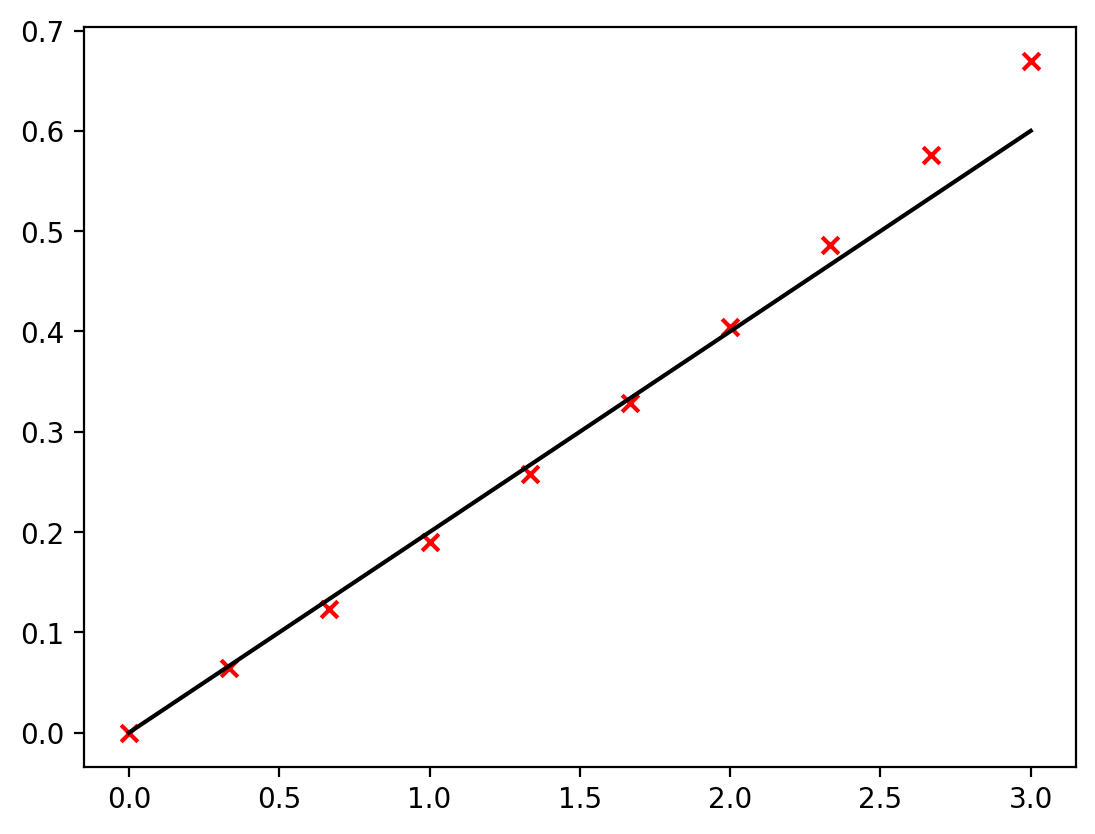

In [5]:
v_pred = lambda c_BE, tau_B, sigma_E: c_BE / (tau_B * sigma_E)
v_pred_list = v_pred(c_BE_list, bump_pop['tau_B'], edge_pop['sigma_E'])

plt.scatter(c_BE_list, v_list, marker = 'x', color='red')
plt.plot(c_BE_list, v_pred_list, color='black')

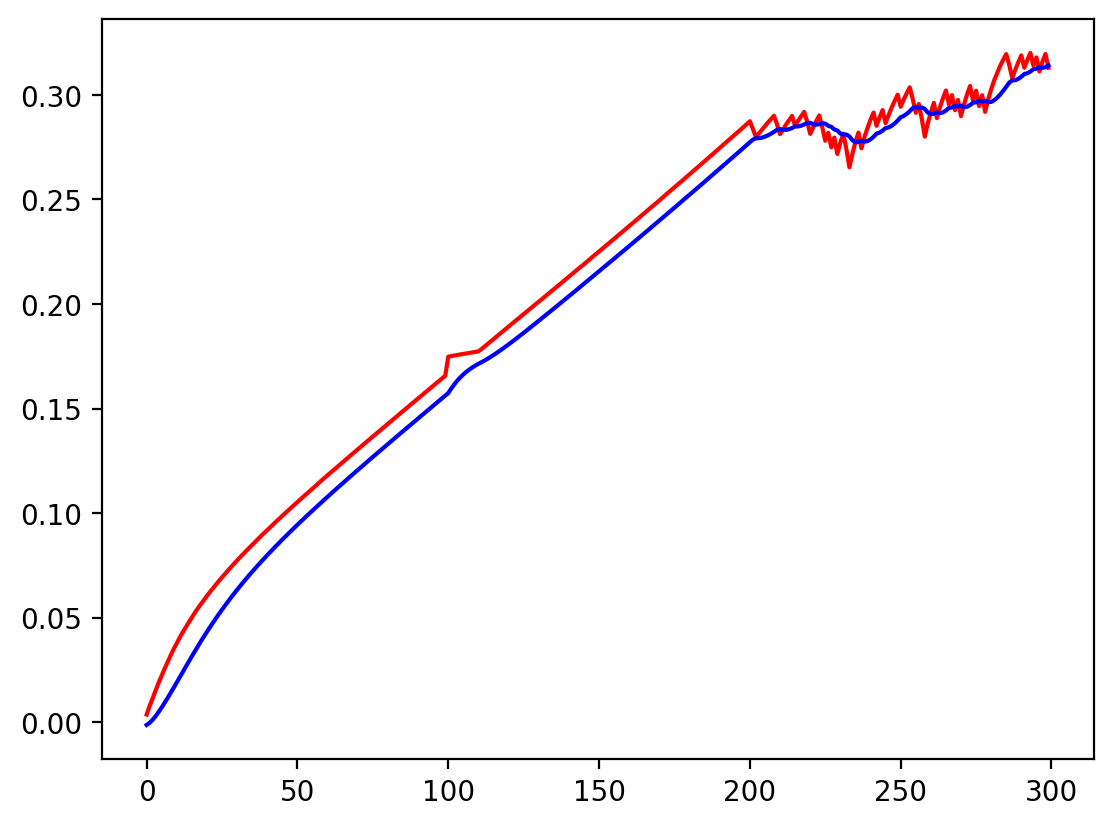

In [5]:
plt.plot(runner.mon.theta_E[t_start:t_start+300], color='red')
plt.plot(runner.mon.theta_B[t_start:t_start+300], color='blue')

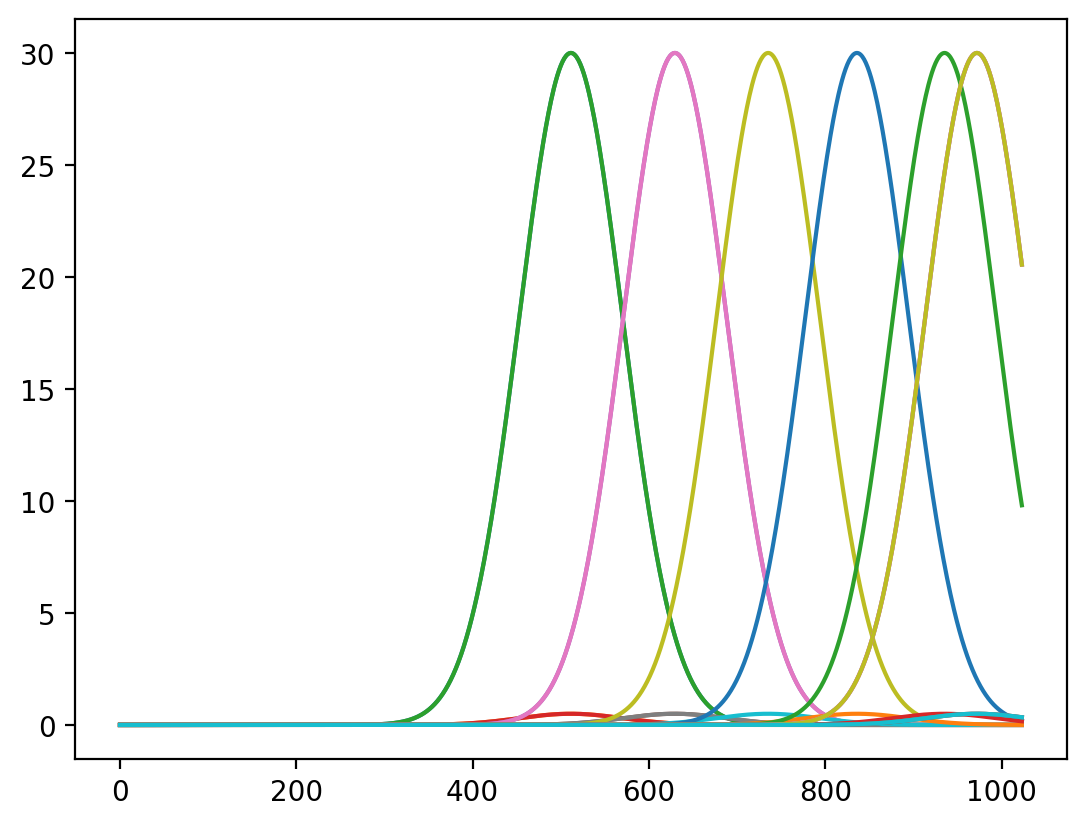

In [16]:
for t in range(200,300, 10):
    plt.plot(runner.mon.I_BE[t,:])
    plt.plot(runner.mon.I_EB[t,:])

In [8]:
model.cue_L_all

array([0., 0., 0., ..., 1., 0., 0.], shape=(1100,))